Step 3.1 — New notebook imports

In [2]:
%pip install imbalanced-learn

Defaulting to user installation because normal site-packages is not writeable

   ---------------------------------------- 0/2 [sklearn-compat]
   ---------------------------------------- 0/2 [sklearn-compat]
   ---------------------------------------- 0/2 [sklearn-compat]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalan


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\vashi\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np

from imblearn.over_sampling import SMOTE

Step 3.2 — Processed data load

In [4]:
X_train_processed = pd.read_csv(
    "../data/processed/X_train_processed.csv"
)

X_test_processed = pd.read_csv(
    "../data/processed/X_test_processed.csv"
)

y_train = pd.read_csv(
    "../data/processed/y_train.csv"
).squeeze()

y_test = pd.read_csv(
    "../data/processed/y_test.csv"
).squeeze()

In [5]:
print(X_train_processed.shape)
print(X_test_processed.shape)

print(y_train.shape)
print(y_test.shape)

(4000, 30)
(1000, 30)
(4000,)
(1000,)


Step 3.3 — Before SMOTE distribution

In [6]:
print("Before SMOTE:")
print(y_train.value_counts())

Before SMOTE:
Fraudulent
0    3614
1     386
Name: count, dtype: int64


In [7]:
print("\nPercentage:")
print(y_train.value_counts(normalize=True) * 100)


Percentage:
Fraudulent
0    90.35
1     9.65
Name: proportion, dtype: float64


Step 3.4 — SMOTE object

In [8]:
smote = SMOTE(
    random_state=42
)

Step 3.5 — Apply SMOTE

In [10]:
X_train_smote, y_train_smote = smote.fit_resample(
    X_train_processed,
    y_train
)

Step 3.6 — After SMOTE

In [11]:
print("After SMOTE:")
print(y_train_smote.value_counts())

After SMOTE:
Fraudulent
0    3614
1    3614
Name: count, dtype: int64


In [12]:
print("\nAfter SMOTE percentage:")
print(
    y_train_smote.value_counts(normalize=True) * 100
)


After SMOTE percentage:
Fraudulent
0    50.0
1    50.0
Name: proportion, dtype: float64


Step 3.7 — Shape check

In [13]:
print("Before SMOTE:", X_train_processed.shape)
print("After SMOTE :", X_train_smote.shape)
print("Test data   :", X_test_processed.shape)

Before SMOTE: (4000, 30)
After SMOTE : (7228, 30)
Test data   : (1000, 30)


Step 3.8 — Verify test set untouched

In [14]:
print("Test target distribution:")
print(y_test.value_counts())

print("\nTest target percentage:")
print(
    y_test.value_counts(normalize=True) * 100
)

Test target distribution:
Fraudulent
0    904
1     96
Name: count, dtype: int64

Test target percentage:
Fraudulent
0    90.4
1     9.6
Name: proportion, dtype: float64


Step 3.9 — Before vs After visualization

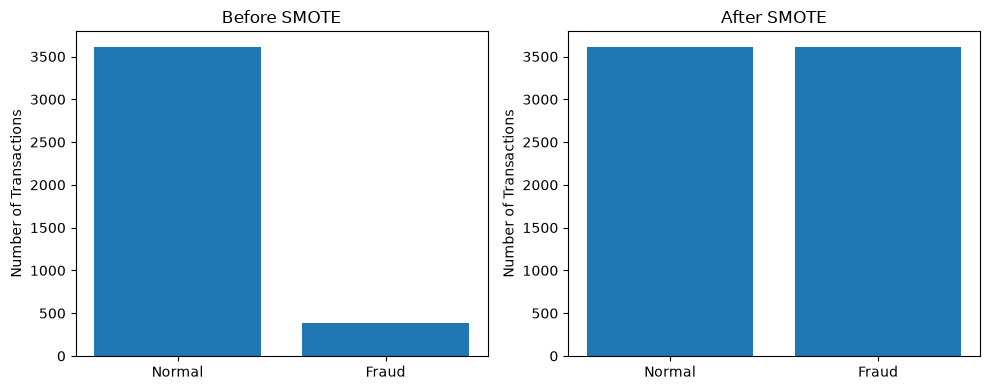

In [15]:
import matplotlib.pyplot as plt

before = y_train.value_counts()
after = y_train_smote.value_counts()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(
    ["Normal", "Fraud"],
    [before[0], before[1]]
)

axes[0].set_title("Before SMOTE")
axes[0].set_ylabel("Number of Transactions")

axes[1].bar(
    ["Normal", "Fraud"],
    [after[0], after[1]]
)

axes[1].set_title("After SMOTE")
axes[1].set_ylabel("Number of Transactions")

plt.tight_layout()
plt.show()

Step 3.10 — Save SMOTE data

In [16]:
X_train_smote.to_csv(
    "../data/processed/X_train_smote.csv",
    index=False
)

y_train_smote.to_csv(
    "../data/processed/y_train_smote.csv",
    index=False
)

In [17]:
import os

files = [
    "X_train_smote.csv",
    "y_train_smote.csv"
]

for file in files:
    path = os.path.join("../data/processed", file)
    print(
        file,
        "→",
        "Created" if os.path.exists(path) else "Missing"
    )

X_train_smote.csv → Created
y_train_smote.csv → Created
